<a href="https://colab.research.google.com/github/aitmansourleilaencg-a11y/GESTION-DES-STOCKS-ET-ENTREPOTS-1/blob/main/projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q xgboost prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("sales_data.csv")
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(by=['sku', 'date'])
df.head()

,date,sku,sales
0,2023-01-01,SKU_1,24
1,2023-01-02,SKU_1,35
2,2023-01-03,SKU_1,37
3,2023-01-04,SKU_1,34
4,2023-01-05,SKU_1,19


In [5]:
# Variables temporelles
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek

# Lags (historique)
df['lag_1'] = df.groupby('sku')['sales'].shift(1)
df['lag_7'] = df.groupby('sku')['sales'].shift(7)

# Moyennes mobiles
df['rolling_mean_7'] = df.groupby('sku')['sales'].shift(1).rolling(7).mean()

df = df.dropna()

In [6]:
X = df[['day', 'month', 'dayofweek', 'lag_1', 'lag_7', 'rolling_mean_7']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [7]:
model = XGBRegressor(n_estimators=100, max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 5.329445838928223
RMSE: 6.388055634640306


In [8]:
future_preds = []
last_data = df.tail(30)

for i in range(30):
    X_future = last_data[['day', 'month', 'dayofweek', 'lag_1', 'lag_7', 'rolling_mean_7']].iloc[-1:]
    pred = model.predict(X_future)[0]

    future_preds.append(pred)

    new_row = last_data.iloc[-1:].copy()
    new_row['sales'] = pred
    last_data = pd.concat([last_data, new_row])

In [9]:
# Paramètres
lead_time = 5  # jours
service_level = 1.65  # sécurité

demand_mean = np.mean(future_preds)
demand_std = np.std(future_preds)

# Stock de sécurité
safety_stock = service_level * demand_std * np.sqrt(lead_time)

# Point de commande
reorder_point = demand_mean * lead_time + safety_stock

print("Stock de sécurité:", safety_stock)
print("Point de commande:", reorder_point)

Stock de sécurité: 2.8148743511677843e-05
Point de commande: 234.57810737237634


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


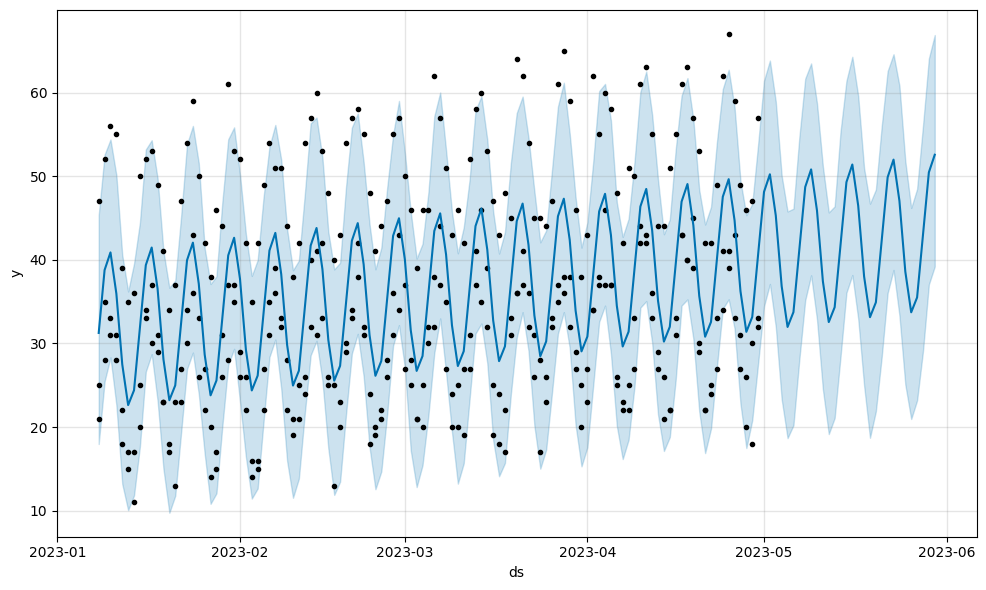

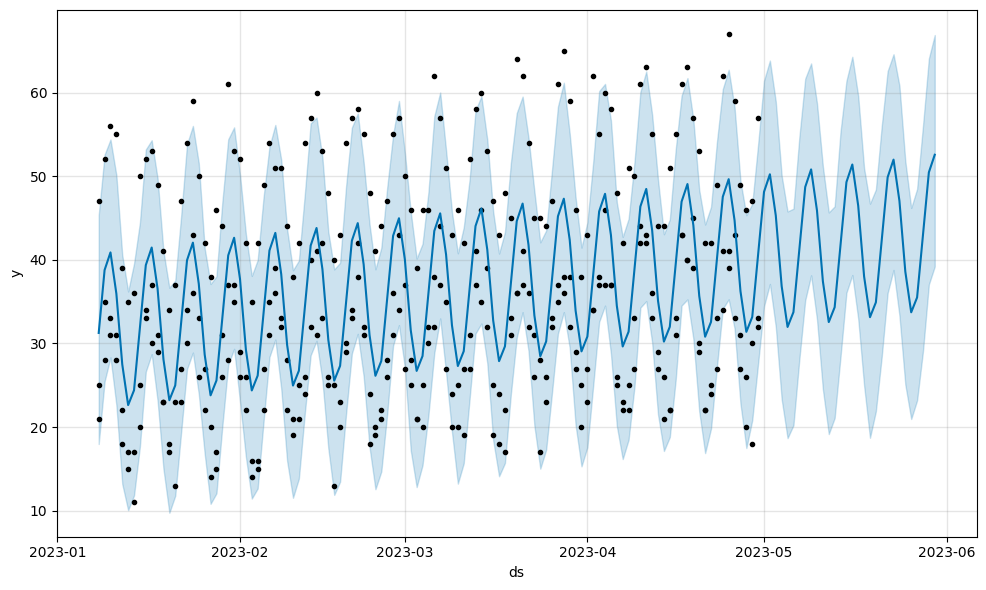

In [10]:
from prophet import Prophet

df_prophet = df[['date', 'sales']].rename(columns={'date':'ds','sales':'y'})

model_p = Prophet()
model_p.fit(df_prophet)

future = model_p.make_future_dataframe(periods=30)
forecast = model_p.predict(future)

model_p.plot(forecast)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00


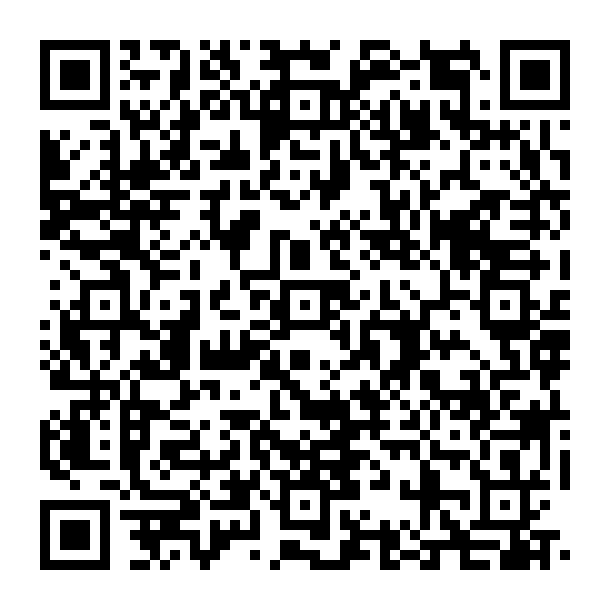

In [13]:
# code QR

!pip install qrcode[pil]

import qrcode

url = "https://colab.research.google.com/drive/1JAfARyvZreXZJZoqQKI4NcFI5P21jeK5?usp=sharing"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)
qr.add_data(url)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")
img.save("qrcode_colab.png")

from IPython.display import Image
Image("qrcode_colab.png")